# 03 — Exploratory Data Analysis

## UAE Used Car Market Analysis

Eleven charts, built on the full 28,109-listing dataset from
`02_cleaning.ipynb`. Same UAE-themed visual style throughout — black,
red, gold, green.

Price and mileage charts run on a filtered subset that drops nulls and
the rows flagged as suspect in the cleaning notebook (about 22.6% of
AutoTraders.ae listings have no displayed price — "Call for Price" dealer
listings — plus a small set of parsing artifacts). Charts based on
listing counts or brand/model composition use everything, since those
fields aren't affected either way.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, FixedLocator, NullLocator
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

UAE_RED = "#C8102E"
UAE_GREEN = "#00732F"
UAE_GOLD = "#D4AF37"
UAE_BLACK = "#1A1A1A"
UAE_SAND = "#F5F1E8"
UAE_PALETTE_4 = [UAE_BLACK, UAE_RED, UAE_GOLD, UAE_GREEN]
UAE_GRADIENT = sns.blend_palette([UAE_BLACK, UAE_RED, UAE_GOLD], as_cmap=True)

def aed_formatter(x, pos):
    if abs(x) >= 1_000_000:
        return f"AED {x/1_000_000:.1f}M"
    elif abs(x) >= 1_000:
        return f"AED {x/1_000:.0f}K"
    return f"AED {x:.0f}"

def count_formatter(x, pos):
    return f"{x:,.0f}"

AED_FORMAT = FuncFormatter(aed_formatter)
COUNT_FORMAT = FuncFormatter(count_formatter)

CHART_DIR = "../data/processed"

df = pd.read_csv("../data/processed/uae_cars_final_clean.csv")
print(f"Full dataset: {df.shape}")

df_price = df[df["price_aed"].notna() & ~df["price_suspect"]].copy()
df_mileage = df[df["mileage_km"].notna() & ~df["mileage_suspect"]].copy()
print(f"Price-safe subset: {len(df_price)} ({100*len(df_price)/len(df):.1f}%)")
print(f"Mileage-safe subset: {len(df_mileage)} ({100*len(df_mileage)/len(df):.1f}%)")

Full dataset: (28109, 16)
Price-safe subset: 24232 (86.2%)
Mileage-safe subset: 24213 (86.1%)


## Chart 1 — Price Distribution

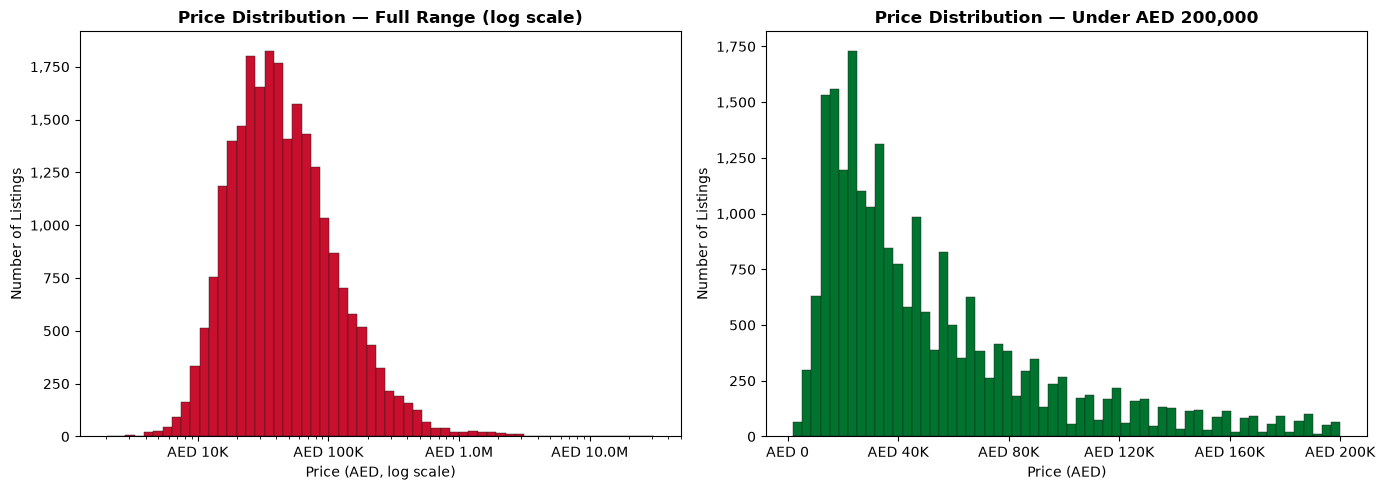

Median price: AED 42,000
% of listings under AED 100,000: 81.3%
Max price in dataset: AED 31,000,000


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_bins = np.logspace(np.log10(max(df_price["price_aed"].min(), 1)), np.log10(df_price["price_aed"].max()), 60)
axes[0].hist(df_price["price_aed"], bins=log_bins, color=UAE_RED, edgecolor=UAE_BLACK, linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_title("Price Distribution — Full Range (log scale)", fontweight="bold")
axes[0].set_xlabel("Price (AED, log scale)")
axes[0].set_ylabel("Number of Listings")
axes[0].xaxis.set_major_formatter(AED_FORMAT)
axes[0].yaxis.set_major_formatter(COUNT_FORMAT)

under_200k = df_price[df_price["price_aed"] < 200_000]
axes[1].hist(under_200k["price_aed"], bins=60, color=UAE_GREEN, edgecolor=UAE_BLACK, linewidth=0.3)
axes[1].set_title("Price Distribution — Under AED 200,000", fontweight="bold")
axes[1].set_xlabel("Price (AED)")
axes[1].set_ylabel("Number of Listings")
axes[1].xaxis.set_major_formatter(AED_FORMAT)
axes[1].yaxis.set_major_formatter(COUNT_FORMAT)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(6))

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

median_price = df_price["price_aed"].median()
pct_under_100k = (df_price["price_aed"] < 100_000).mean() * 100
print(f"Median price: AED {median_price:,.0f}")
print(f"% of listings under AED 100,000: {pct_under_100k:.1f}%")
print(f"Max price in dataset: AED {df_price['price_aed'].max():,.0f}")

On a log scale the distribution looks close to log-normal — one
clean peak somewhere in the AED 30K-50K range, tapering off smoothly all
the way out to the multi-million-dirham exotics rather than showing any
weird breaks or spikes that would suggest leftover bad data. The
zoomed-in panel makes the concentration clearer: most of the market sits
between roughly AED 15,000 and 60,000, with that sharp early peak
matching what you'd expect from a market where older, cheaper cars simply
outnumber everything else.

## Chart 2 — Median Price by Brand (Top 20)

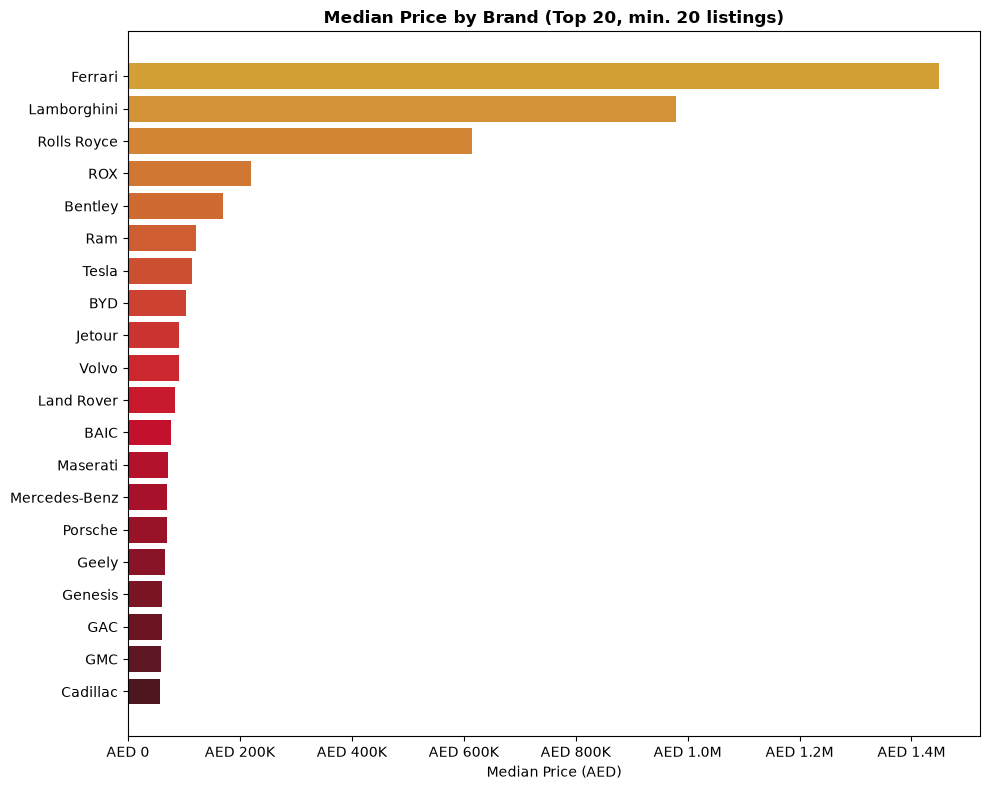

brand
Ferrari          1450000.0
Lamborghini       979997.5
Rolls Royce       614500.0
ROX               220000.0
Bentley           169600.0
Ram               121500.0
Tesla             114000.0
BYD               103500.0
Jetour             92000.0
Volvo              91000.0
Land Rover         85000.0
BAIC               76500.0
Maserati           72500.0
Mercedes-Benz      70500.0
Porsche            69000.0
Geely              66000.0
Genesis            61500.0
GAC                61000.0
GMC                60000.0
Cadillac           58000.0
Name: price_aed, dtype: float64


In [3]:
brand_counts = df_price["brand"].value_counts()
eligible_brands = brand_counts[brand_counts >= 20].index

top_brands = (
    df_price[df_price["brand"].isin(eligible_brands)]
    .groupby("brand")["price_aed"].median()
    .sort_values(ascending=False)
)
top_20 = top_brands.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [UAE_GRADIENT(x) for x in np.linspace(0.15, 0.95, len(top_20))]
ax.barh(top_20.index[::-1], top_20.values[::-1], color=colors)
ax.set_title("Median Price by Brand (Top 20, min. 20 listings)", fontweight="bold")
ax.set_xlabel("Median Price (AED)")
ax.xaxis.set_major_formatter(AED_FORMAT)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_brand_prices.png", dpi=150, bbox_inches="tight")
plt.show()

print(top_20)

Ferrari, Lamborghini, and Rolls-Royce sit at the top, which is
exactly what you'd expect once genuine exotic-dealer inventory is in the
mix. One thing that caught my eye: ROX — the newer UAE-based EV brand —
lands in 4th place, ahead of Land Rover, Mercedes-Benz, and Porsche. That
surprised me enough that I'd want to look at those specific ROX listings
before repeating the number anywhere, since it's positioned more as a
budget EV entrant and a median that high doesn't quite square with that.
Land Rover sitting lower than expected makes more sense on reflection —
this is a median across every Land Rover model, so cheaper Discoverys and
Freelanders are dragging the average down against the pricier Range
Rovers.

## Chart 3 — Median Price by Emirate

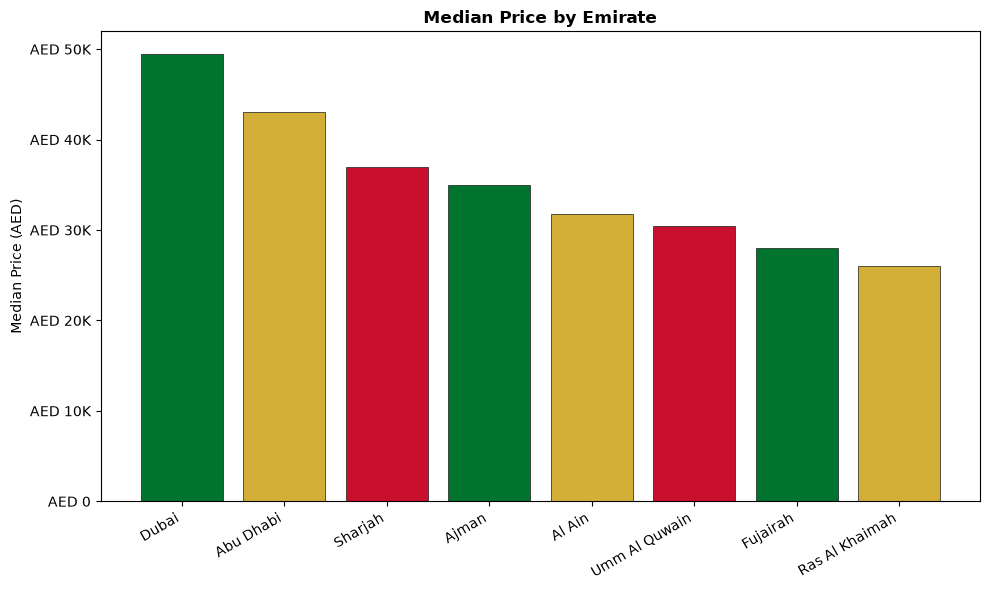

                median_price      n
city                               
Dubai                49500.0  10390
Abu Dhabi            43000.0   4257
Sharjah              37000.0   4629
Ajman                35000.0   2561
Al Ain               31750.0   1382
Umm Al Quwain        30500.0    298
Fujairah             28000.0    218
Ras Al Khaimah       26000.0    497


In [4]:
city_stats = df_price.groupby("city").agg(
    median_price=("price_aed", "median"),
    n=("price_aed", "count"),
).sort_values("median_price", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [UAE_GREEN if i % 3 == 0 else UAE_GOLD if i % 3 == 1 else UAE_RED for i in range(len(city_stats))]
ax.bar(city_stats.index, city_stats["median_price"], color=colors, edgecolor=UAE_BLACK, linewidth=0.5)
ax.set_title("Median Price by Emirate", fontweight="bold")
ax.set_ylabel("Median Price (AED)")
ax.yaxis.set_major_formatter(AED_FORMAT)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_city_prices.png", dpi=150, bbox_inches="tight")
plt.show()

print(city_stats)

A clean gradient from Dubai down to Ras Al Khaimah, roughly
tracking each emirate's general cost of living and population. Every
emirate has a solid sample size here — nothing needs to get excluded for
being too small to trust, which wasn't always true with a smaller
dataset.

## Chart 4 — Price Distribution by Emirate

Emirates with at least 100 listings: ['Dubai', 'Abu Dhabi', 'Sharjah', 'Ajman', 'Al Ain', 'Umm Al Quwain', 'Fujairah', 'Ras Al Khaimah']


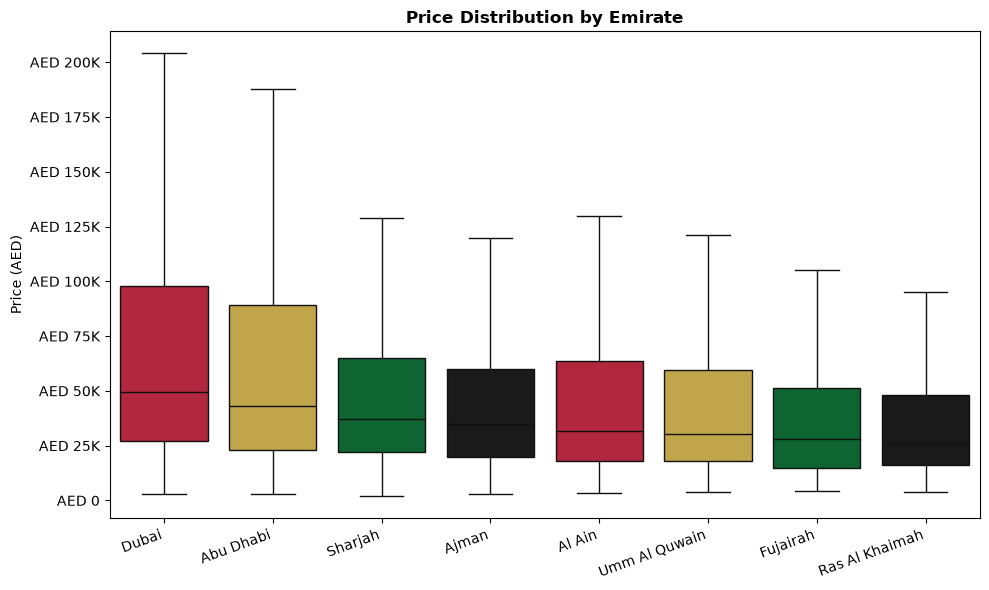

In [5]:
RELIABILITY_THRESHOLD = 100
reliable_cities = city_stats[city_stats["n"] >= RELIABILITY_THRESHOLD].index.tolist()
print(f"Emirates with at least {RELIABILITY_THRESHOLD} listings: {reliable_cities}")

df_reliable = df_price[df_price["city"].isin(reliable_cities)]

fig, ax = plt.subplots(figsize=(10, 6))
order = df_reliable.groupby("city")["price_aed"].median().sort_values(ascending=False).index
palette = {c: [UAE_RED, UAE_GOLD, UAE_GREEN, UAE_BLACK][i % 4] for i, c in enumerate(order)}
sns.boxplot(data=df_reliable, x="city", y="price_aed", order=order, palette=palette, ax=ax, showfliers=False)
ax.set_title("Price Distribution by Emirate", fontweight="bold")
ax.set_ylabel("Price (AED)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(AED_FORMAT)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_city_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

The boxes overlap a lot more than Chart 3's bar heights might
suggest — Dubai and Abu Dhabi have the widest spread and the highest
medians, but from Sharjah down to Ras Al Khaimah the boxes are basically
sitting on top of each other. That overlap is the tell that this isn't
really a location premium so much as different cities having different
mixes of cars for sale — Chart 8 digs into that directly.

## Chart 5 — Depreciation Curves by Brand Segment

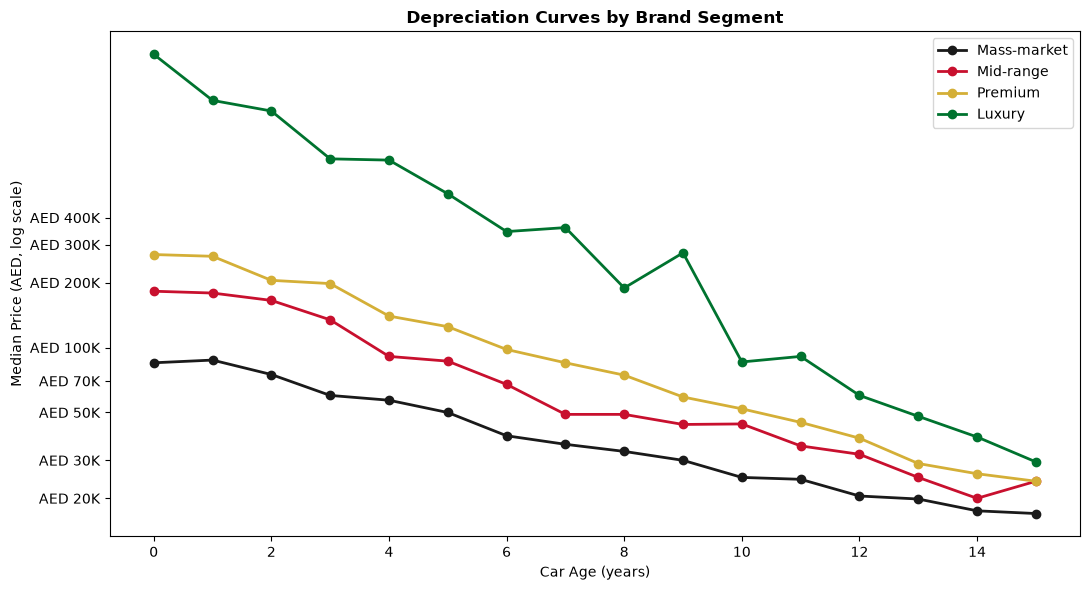

brand_segment
Luxury           602
Mass-market    14290
Mid-range       1706
Premium         7634
dtype: int64


In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

for i, segment in enumerate(["Mass-market", "Mid-range", "Premium", "Luxury"]):
    seg_data = df_price[(df_price["brand_segment"] == segment) & (df_price["car_age"] <= 15)]
    curve = seg_data.groupby("car_age")["price_aed"].median()
    ax.plot(curve.index, curve.values, marker="o", label=segment, color=UAE_PALETTE_4[i], linewidth=2)

ax.set_yscale("log")
ax.yaxis.set_major_locator(FixedLocator([20000, 30000, 50000, 70000, 100000, 200000, 300000, 400000]))
ax.yaxis.set_minor_locator(NullLocator())
ax.yaxis.set_major_formatter(AED_FORMAT)
ax.set_title("Depreciation Curves by Brand Segment", fontweight="bold")
ax.set_xlabel("Car Age (years)")
ax.set_ylabel("Median Price (AED, log scale)")
ax.legend()

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_depreciation.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_price.groupby("brand_segment").size())

Luxury drops the fastest early on, which tracks with how new-car
pricing works generally — a bigger number to lose a percentage of. There's
a small bump in the Luxury curve around year 8-9 rather than a clean
monotonic decline, which is probably a specific model generation holding
demand at that age rather than noise, though with this being the
smallest of the four segments it's worth taking with a grain of salt.
The more interesting thing is what happens at the far right: Mid-range
actually dips below Mass-market by year 14-15. Older mainstream American
and European cars seem to lose value harder in their final years than
economy Japanese and Korean cars do at the same age.

## Chart 6 — Value Retention by Model

A model-level view: median price when a car is 0-2 years old versus
6-9 years old, expressed as a percentage. Only models with at least 8
listings in both brackets make the cut, so this isn't built on 2-3
noisy data points per model.

45 models had enough listings in both brackets to compare


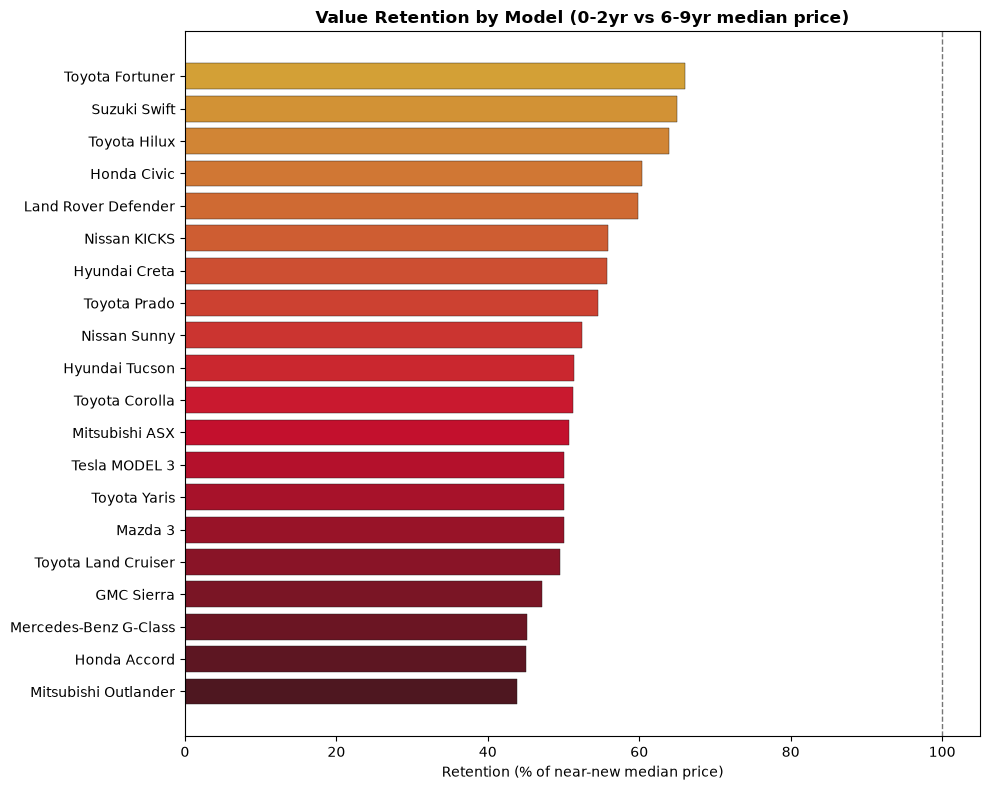

                       median_young  count_young  median_old  count_old  \
brand_model                                                               
Toyota Fortuner            115900.0           17     76500.0         40   
Suzuki Swift                40000.0            9     26000.0         13   
Toyota Hilux                97000.0           30     62000.0         21   
Honda Civic                 62999.5            8     38000.0         37   
Land Rover Defender        345000.0           47    206497.5         22   
Nissan KICKS                49749.5           32     27800.0         81   
Hyundai Creta               53000.0           11     29500.0         24   
Toyota Prado               209950.0           22    114500.0         41   
Nissan Sunny                31500.0           14     16500.0         49   
Hyundai Tucson              70000.0           17     35950.0         68   
Toyota Corolla              62500.0           21     32000.0         67   
Mitsubishi ASX           

In [7]:
YOUNG_BRACKET = (0, 2)
OLD_BRACKET = (6, 9)
MIN_LISTINGS_PER_BRACKET = 8

df_price["brand_model"] = df_price["brand"] + " " + df_price["model"].astype(str)

young = df_price[df_price["car_age"].between(*YOUNG_BRACKET)].groupby("brand_model")["price_aed"].agg(["median", "count"])
old = df_price[df_price["car_age"].between(*OLD_BRACKET)].groupby("brand_model")["price_aed"].agg(["median", "count"])

retention = young.join(old, lsuffix="_young", rsuffix="_old", how="inner")
retention = retention[
    (retention["count_young"] >= MIN_LISTINGS_PER_BRACKET) &
    (retention["count_old"] >= MIN_LISTINGS_PER_BRACKET)
]
retention["retention_pct"] = (retention["median_old"] / retention["median_young"] * 100).round(1)
retention = retention.sort_values("retention_pct", ascending=False)

print(f"{len(retention)} models had enough listings in both brackets to compare")

top_n = retention.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [UAE_GRADIENT(x) for x in np.linspace(0.15, 0.95, len(top_n))]
ax.barh(top_n.index[::-1], top_n["retention_pct"][::-1], color=colors, edgecolor=UAE_BLACK, linewidth=0.3)
ax.axvline(100, color=UAE_BLACK, linestyle="--", linewidth=1, alpha=0.6)
ax.set_title(f"Value Retention by Model ({YOUNG_BRACKET[0]}-{YOUNG_BRACKET[1]}yr vs {OLD_BRACKET[0]}-{OLD_BRACKET[1]}yr median price)", fontweight="bold")
ax.set_xlabel("Retention (% of near-new median price)")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_value_retention.png", dpi=150, bbox_inches="tight")
plt.show()

print(top_n[["median_young", "count_young", "median_old", "count_old", "retention_pct"]].head(20))

Toyota Fortuner tops the list, with the Suzuki Swift and Hilux
close behind — practical, high-demand vehicles holding onto more of
their price than most. What's genuinely surprising is where the Land
Cruiser lands: solidly mid-pack, behind several other Toyota models,
despite its reputation as the go-to example of a GCC car that holds its
value. And the Mercedes G-Class shows up near the bottom, which runs
completely against how it's normally talked about in this market. My
best guess is that recent G-Class pricing has jumped enough on the
near-new side that the ratio makes it look like poor retention, when
really it's the young-car baseline that moved, not the car losing value
faster. Worth checking against actual listing prices before writing that
up as a real finding rather than a pricing-cycle artifact.

## Chart 7 — Price Tier Composition by Car Age

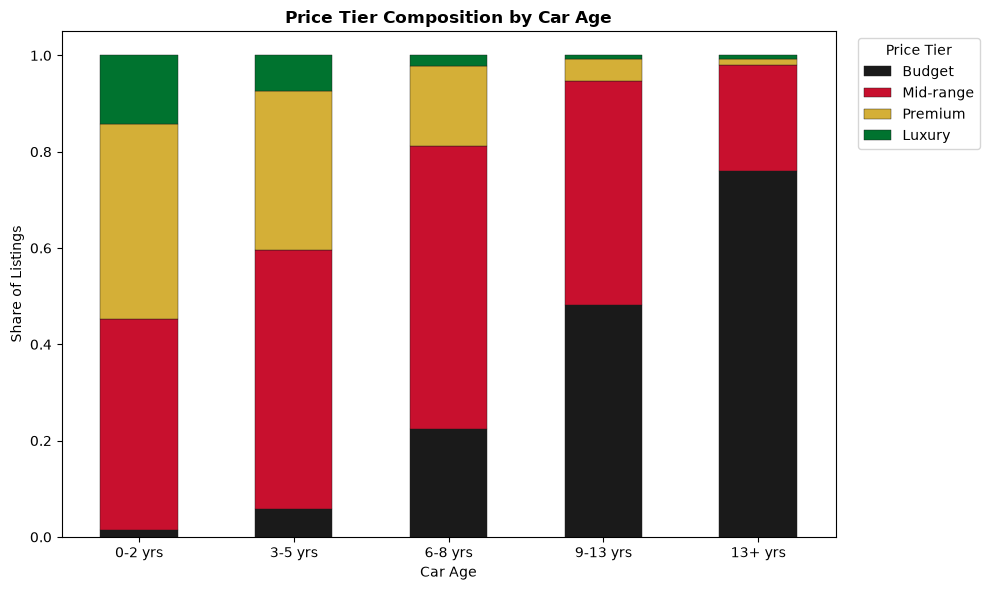

price_tier  Budget  Mid-range  Premium  Luxury
age_group                                     
0-2 yrs        1.5       43.9     40.4    14.3
3-5 yrs        5.8       53.8     33.0     7.4
6-8 yrs       22.3       58.9     16.5     2.2
9-13 yrs      48.2       46.5      4.6     0.7
13+ yrs       76.0       22.0      1.3     0.7


In [8]:
age_bins = [0, 2, 5, 8, 13, 100]
age_labels = ["0-2 yrs", "3-5 yrs", "6-8 yrs", "9-13 yrs", "13+ yrs"]
df_price["age_group"] = pd.cut(df_price["car_age"], bins=age_bins, labels=age_labels, right=True)

composition = pd.crosstab(df_price["age_group"], df_price["price_tier"], normalize="index")
composition = composition[["Budget", "Mid-range", "Premium", "Luxury"]]

fig, ax = plt.subplots(figsize=(10, 6))
composition.plot(kind="bar", stacked=True, color=UAE_PALETTE_4, ax=ax, edgecolor=UAE_BLACK, linewidth=0.3)
ax.set_title("Price Tier Composition by Car Age", fontweight="bold")
ax.set_ylabel("Share of Listings")
ax.set_xlabel("Car Age")
ax.legend(title="Price Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_tier_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

print((composition * 100).round(1))

About as textbook as this kind of chart gets — Budget is almost
nonexistent among 0-2 year old cars and dominates everything by the time
you're looking at 13+ year old ones. Straightforward depreciation
working exactly the way you'd expect it to.

## Chart 8 — Brand Segment Composition by Emirate

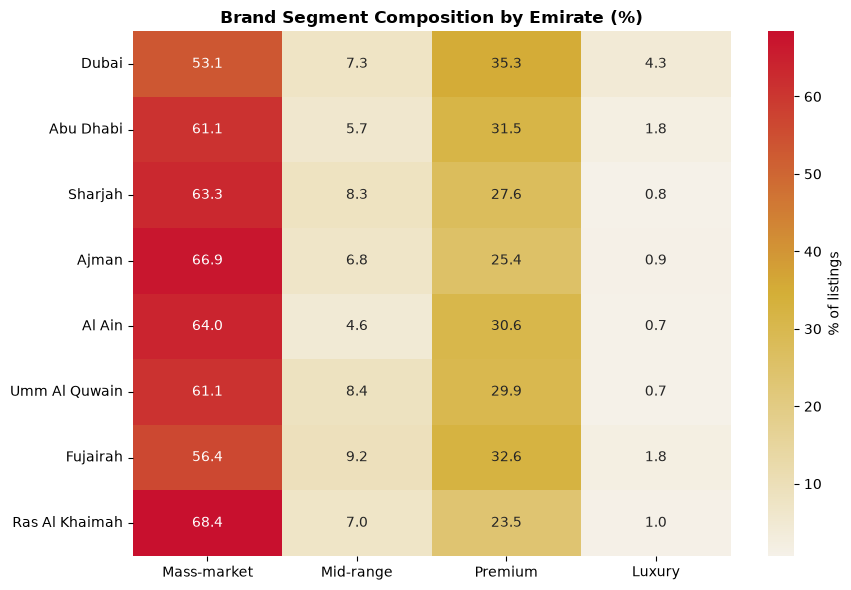

In [9]:
heatmap_data = pd.crosstab(df_price["city"], df_price["brand_segment"], normalize="index")
heatmap_data = heatmap_data[["Mass-market", "Mid-range", "Premium", "Luxury"]]
heatmap_data = heatmap_data.loc[reliable_cities]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heatmap_data * 100, annot=True, fmt=".1f", cmap=sns.blend_palette([UAE_SAND, UAE_GOLD, UAE_RED], as_cmap=True),
    ax=ax, cbar_kws={"label": "% of listings"},
)
ax.set_title("Brand Segment Composition by Emirate (%)", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_segment_emirate_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

This is the chart that actually explains Chart 4. Dubai has both
the lowest Mass-market share and the highest Luxury share of any emirate
in the dataset, and Ras Al Khaimah sits at the opposite end — highest
Mass-market share, lowest Luxury. So it's not that a car costs more just
for being listed in Dubai; Dubai's overall mix of what's for sale skews
more expensive to begin with.

## Chart 9 — Annual Mileage by Brand Segment

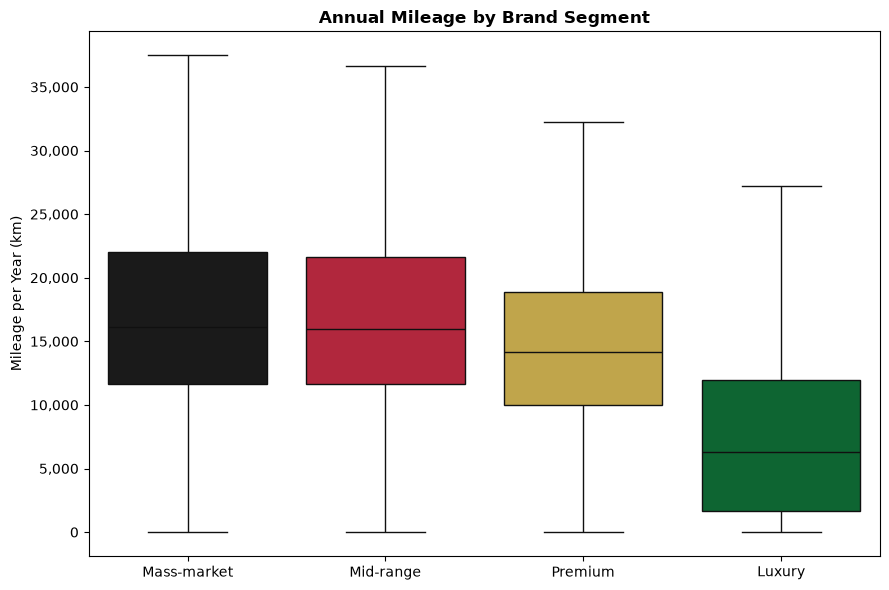

brand_segment
Mass-market    16150.000000
Mid-range      16000.000000
Premium        14166.666667
Luxury          6333.333333
Name: mileage_per_year, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
order = ["Mass-market", "Mid-range", "Premium", "Luxury"]
sns.boxplot(
    data=df_mileage, x="brand_segment", y="mileage_per_year", order=order,
    palette=UAE_PALETTE_4, ax=ax, showfliers=False,
)
ax.set_title("Annual Mileage by Brand Segment", fontweight="bold")
ax.set_ylabel("Mileage per Year (km)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(COUNT_FORMAT)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_mileage_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_mileage.groupby("brand_segment")["mileage_per_year"].median().reindex(order))

Mass-market and Mid-range track each other closely, Premium drops
off a bit, and Luxury is in a different world entirely — noticeably lower
annual mileage than the other three. Fits the general idea that
expensive cars in this market tend to be lease vehicles or status
purchases driven sparingly, rather than daily drivers racking up real
distance.

## Chart 10 — Price Distribution by Source

C:\Users\Sigma\AppData\Local\Temp\ipykernel_24232\2844469213.py:3: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.boxplot(data=df_price, x="source", y="price_aed", order=order, palette=UAE_PALETTE_4, ax=ax, showfliers=False)


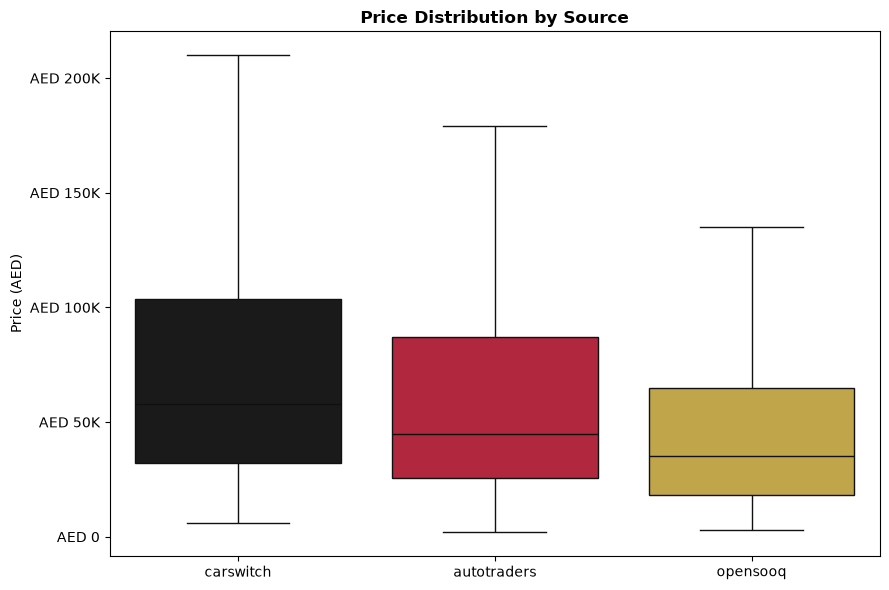

source
carswitch      58000.0
autotraders    45000.0
opensooq       35000.0
Name: price_aed, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
order = df_price.groupby("source")["price_aed"].median().sort_values(ascending=False).index
sns.boxplot(data=df_price, x="source", y="price_aed", order=order, palette=UAE_PALETTE_4, ax=ax, showfliers=False)
ax.set_title("Price Distribution by Source", fontweight="bold")
ax.set_ylabel("Price (AED)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(AED_FORMAT)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_price_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_price.groupby("source")["price_aed"].median().sort_values(ascending=False))

This one didn't go the way I expected. Going into this I'd have
guessed AutoTraders.ae would show the highest median, since that's where
the genuine exotic dealer inventory (Bentleys, Range Rovers, McLarens)
kept turning up while scraping it. Instead CarSwitch comes out on top,
with AutoTraders.ae in the middle and OpenSooq lowest. My read on this:
CarSwitch is a certified, inspected marketplace, and that positioning
probably carries its own price premium independent of what specific cars
are listed — worth testing directly with `source` as a regression feature
in the next notebook rather than leaving it as a guess.

## Chart 11 — Brand Segment Composition by Source

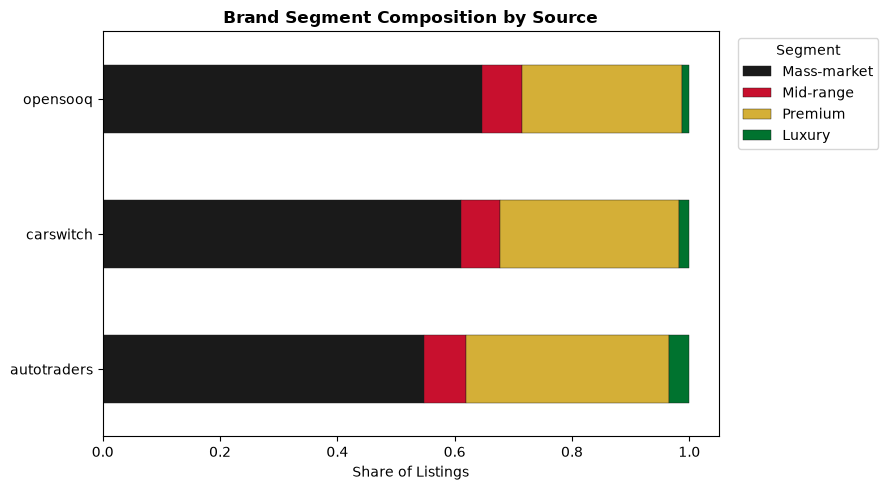

brand_segment  Mass-market  Mid-range  Premium  Luxury
source                                                
autotraders           54.8        7.2     34.5     3.5
carswitch             61.1        6.7     30.4     1.8
opensooq              64.6        6.9     27.3     1.2


In [12]:
source_composition = pd.crosstab(df_price["source"], df_price["brand_segment"], normalize="index")
source_composition = source_composition[["Mass-market", "Mid-range", "Premium", "Luxury"]]

fig, ax = plt.subplots(figsize=(9, 5))
source_composition.plot(kind="barh", stacked=True, color=UAE_PALETTE_4, ax=ax, edgecolor=UAE_BLACK, linewidth=0.3)
ax.set_title("Brand Segment Composition by Source", fontweight="bold")
ax.set_xlabel("Share of Listings")
ax.set_ylabel("")
ax.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart_segment_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

print((source_composition * 100).round(1))

This is what squares Chart 10 with what browsing the listings
actually felt like during scraping — AutoTraders.ae genuinely does carry
the largest Premium-plus-Luxury share of the three sources. It's just
that composition and median price aren't the same thing: OpenSooq's mix
leans hardest toward Mass-market with barely any Mid-range at all, and
CarSwitch's certified-marketplace pricing premium apparently outweighs
its segment mix. Both things are true at once, which is a decent reminder
not to read a composition chart and a price chart as saying the same
thing.

## Next

`04_analysis.ipynb` — regression models and the value-score system,
including `source` as a feature to properly test the Chart 10/11 question
instead of just eyeballing it.